In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,class_likelihood_ratios

In [2]:
df = pd.read_csv(
    "dataset/SMSSpamCollection",
    sep="\t",
    names=["label", "message"]
)

In [4]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.shape

(5572, 2)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [7]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(403)

In [9]:
df["label"].unique()

<StringArray>
['ham', 'spam']
Length: 2, dtype: str

In [10]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

Text(0.5, 1.0, 'Ham vs spam message')

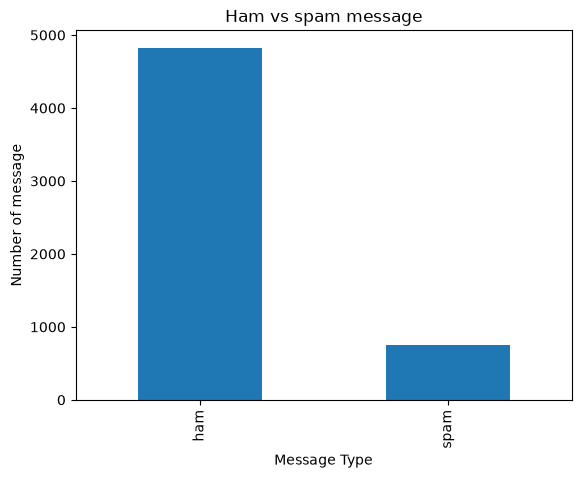

In [14]:
import matplotlib.pyplot as plt 
df["label"].value_counts().plot(kind="bar")
plt.xlabel("Message Type")
plt.ylabel("Number of message")
plt.title("Ham vs spam message")

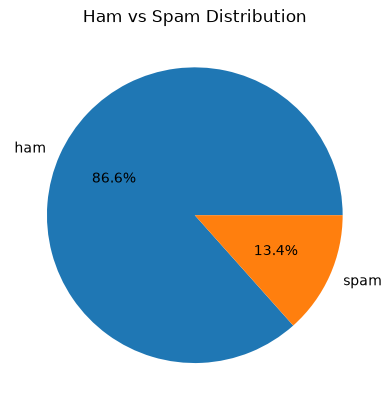

In [12]:
df["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Ham vs Spam Distribution")
plt.ylabel("")

plt.show()

In [15]:
df[df["label"] == "spam"].head(10)

,label,message
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
5,spam,FreeMsg Hey there darling it's been 3 week's n...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."
12,spam,URGENT! You have won a 1 week FREE membership ...
15,spam,"XXXMobileMovieClub: To use your credit, click ..."
19,spam,England v Macedonia - dont miss the goals/team...
34,spam,Thanks for your subscription to Ringtone UK yo...
42,spam,07732584351 - Rodger Burns - MSG = We tried to...


In [16]:
df[df["label"] == "ham"].head(10)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
10,ham,I'm gonna be home soon and i don't want to tal...
13,ham,I've been searching for the right words to tha...
14,ham,I HAVE A DATE ON SUNDAY WITH WILL!!
16,ham,Oh k...i'm watching here:)


In [17]:
X = df["message"]
y=df["label"]

In [18]:
df["label"] = df["label"].map(
    {
        "ham":0,
        "spam":1
    }
)

In [20]:
from sklearn.model_selection import train_test_split

In [22]:
x=df["message"]
y=df["label"]

x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()

In [24]:
x_train_vectorized = vectorizer.fit_transform(x_train)
x_test_vectorized = vectorizer.transform(x_test)

In [27]:
x_test_vectorized

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 14110 stored elements and shape (1115, 7668)>

In [28]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(
    x_train_vectorized,
    y_train
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3859., 598.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.14,-2.01]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 7668)","[[ 0., 0., 1.,..., 1., 0., 1.], [10.,21., 0.,..., 0., 1., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 7668)","[[-10.96,-10.96,-10.27,...,-10.27,-10.96,-10.27], [ -7.59, -6.89, -9.98,..., -9.98, -9.29, -9.98]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7668


In [29]:
y_pred = model.predict(x_test_vectorized)

In [30]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy : ",accuracy)

Accuracy :  0.9874439461883409


In [31]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Ham","Spam"]
    )
)

              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       966
        Spam       0.99      0.92      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



Text(0.5, 1.0, 'Naive Bayes confusion matris')

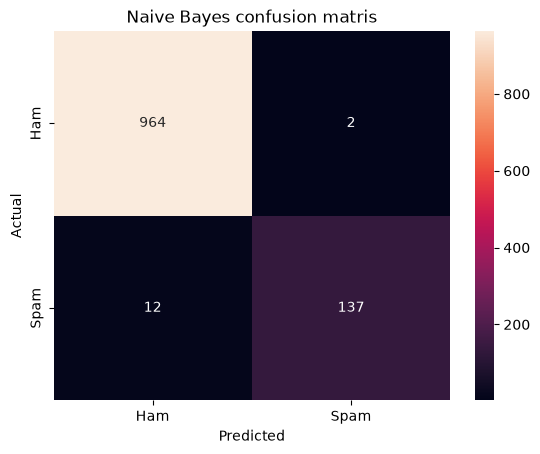

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham","Spam"],
    yticklabels=["Ham","Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes confusion matris")